# Laboratorio 5: Clasificación de tweets usando minería de texto

## Avance

Integrante: Nina Nájera Marakovits - 231088

## 1. Objetivo

El objetivo es preparar los tweets y construir una primera solución para distinguir mensajes sobre desastres reales de otros mensajes. Este avance incluye la descripción de los datos, el análisis exploratorio, el preprocesamiento, las frecuencias de unigramas y bigramas, y un modelo preliminar de clasificación.

In [1]:
from html import unescape
from pathlib import Path
from urllib.parse import unquote
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

SEMILLA = 42
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Carga y descripción de los datos

El archivo contiene cinco variables:

- id: identificador del tweet.
- keyword: palabra clave asociada al tweet.
- location: ubicación declarada por la cuenta.
- text: contenido original del tweet.
- target: clase objetivo, donde 1 representa un desastre real y 0 representa otro tipo de mensaje.

In [2]:
rutas_posibles = [Path("data/raw/train.csv"), Path("../data/raw/train.csv")]
RUTA_DATOS = next(ruta for ruta in rutas_posibles if ruta.exists())
datos = pd.read_csv(RUTA_DATOS)

print(f"Dimensiones: {datos.shape[0]:,} filas y {datos.shape[1]} columnas")
display(datos.head())

Dimensiones: 7,613 filas y 5 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [3]:
perfil_columnas = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "faltantes": datos.isna().sum(),
    "porcentaje_faltante": (datos.isna().mean() * 100).round(2),
    "valores_unicos": datos.nunique(),
})

distribucion_target = datos["target"].value_counts().sort_index().rename_axis("target").to_frame("cantidad")
distribucion_target["porcentaje"] = (distribucion_target["cantidad"] / len(datos) * 100).round(2)

resumen_duplicados = pd.Series({
    "filas_duplicadas_completas": int(datos.duplicated().sum()),
    "registros_con_texto_repetido": int(datos["text"].duplicated(keep=False).sum()),
    "textos_distintos_repetidos": int((datos["text"].value_counts() > 1).sum()),
})

display(perfil_columnas)
display(distribucion_target)
display(resumen_duplicados.to_frame("cantidad"))

,tipo,faltantes,porcentaje_faltante,valores_unicos
id,int64,0,0.00,7613
keyword,object,61,0.80,221
location,object,2533,33.27,3341
text,object,0,0.00,7503
target,int64,0,0.00,2


,cantidad,porcentaje
target,,
0,4342,57.03
1,3271,42.97


,cantidad
filas_duplicadas_completas,0
registros_con_texto_repetido,179
textos_distintos_repetidos,69


### Resultados de la revisión inicial

El conjunto tiene 7,613 registros. La variable location concentra la mayor cantidad de datos faltantes, mientras que text y target están completas. La clase 0 representa cerca del 57 % de los tweets y la clase 1 cerca del 43 %, por lo que existe un desbalance moderado.

No hay filas completamente duplicadas, pero sí hay textos repetidos. Algunos tienen etiquetas diferentes. Estos casos se revisan antes de calcular frecuencias y entrenar el modelo para evitar contar varias veces el mismo mensaje o colocar el mismo texto en entrenamiento y prueba.

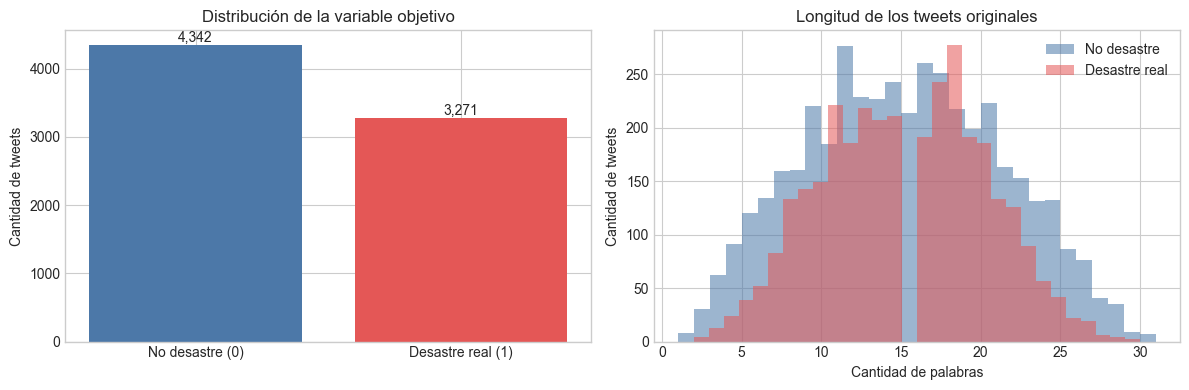

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

colores = ["#4C78A8", "#E45756"]
conteos = datos["target"].value_counts().sort_index()
ax[0].bar(["No desastre (0)", "Desastre real (1)"], conteos.values, color=colores)
ax[0].set_title("Distribución de la variable objetivo")
ax[0].set_ylabel("Cantidad de tweets")
for indice, valor in enumerate(conteos.values):
    ax[0].text(indice, valor + 50, f"{valor:,}", ha="center")

longitud_palabras = datos["text"].str.split().str.len()
for target, color, etiqueta in [(0, colores[0], "No desastre"), (1, colores[1], "Desastre real")]:
    ax[1].hist(longitud_palabras[datos["target"] == target], bins=30, alpha=0.55, color=color, label=etiqueta)
ax[1].set_title("Longitud de los tweets originales")
ax[1].set_xlabel("Cantidad de palabras")
ax[1].set_ylabel("Cantidad de tweets")
ax[1].legend()

plt.tight_layout()
plt.show()

In [5]:
datos_keyword = datos.dropna(subset=["keyword"]).copy()
datos_keyword["keyword"] = datos_keyword["keyword"].map(unquote)

top_keywords = (
    datos_keyword.groupby(["target", "keyword"])
    .size()
    .rename("frecuencia")
    .reset_index()
    .sort_values(["target", "frecuencia"], ascending=[True, False])
    .groupby("target", group_keys=False)
    .head(10)
)

presencia_campos = datos.groupby("target").agg(
    porcentaje_con_keyword=("keyword", lambda serie: round(serie.notna().mean() * 100, 2)),
    porcentaje_con_location=("location", lambda serie: round(serie.notna().mean() * 100, 2)),
)

display(presencia_campos)
display(top_keywords.pivot(index="keyword", columns="target", values="frecuencia").fillna(0).astype(int))

,porcentaje_con_keyword,porcentaje_con_location
target,,
0,99.56,66.42
1,98.72,67.14


target,0,1
keyword,,
armageddon,37,0
body bags,40,0
debris,0,37
deluge,36,0
derailment,0,39
evacuated,0,32
explode,35,0
fear,35,0
harm,37,0


### Interpretación exploratoria

Las dos clases presentan longitudes parecidas y se superponen ampliamente. Por esta razón, la cantidad de palabras no parece suficiente para separar las categorías por sí sola. Las palabras clave muestran diferencias más claras: términos relacionados con daños físicos y emergencias aparecen con mayor fuerza en la clase de desastre real, mientras que varios términos ambiguos también se usan de forma figurada en la clase 0.

La variable location no se usará en el modelo preliminar porque tiene muchos datos faltantes y sus valores no siguen un formato uniforme. El contenido de text será la fuente principal de información.

## 3. Limpieza y preprocesamiento

El preprocesamiento aplicado es el siguiente:

1. Convertir entidades HTML y pasar el texto a minúsculas.
2. Eliminar enlaces completos porque suelen identificar una fuente, pero no describen el evento.
3. Eliminar menciones de usuarios para evitar aprender nombres de cuentas.
4. Quitar el símbolo de los hashtags, pero conservar la palabra que sigue porque puede describir el desastre.
5. Convertir contracciones negativas como don't en do not antes de quitar los apóstrofes.
6. Eliminar números, excepto 911 por su relación directa con emergencias.
7. Eliminar puntuación, emoticones y otros símbolos.
8. Eliminar palabras vacías en inglés. Se conservan no, not y nor porque pueden cambiar el significado de una frase.
9. Eliminar los términos rt, amp y via, que aparecen por la forma en que se publican o codifican los tweets.

Los textos con etiquetas contradictorias se excluyen del análisis y del modelo. Después se conserva una sola copia de cada texto repetido con etiqueta consistente.

In [6]:
STOPWORDS = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor"}
STOPWORDS.update({"rt", "amp", "via"})

def limpiar_texto(texto):
    texto = unescape(str(texto)).lower()
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", "")
    texto = re.sub(r"won['’]t\b", "will not", texto)
    texto = re.sub(r"can['’]t\b", "can not", texto)
    texto = re.sub(r"n['’]t\b", " not", texto)
    texto = re.sub(r"\b\d+\b", lambda coincidencia: " 911 " if coincidencia.group() == "911" else " ", texto)
    tokens = re.findall(r"[a-z]+|911", texto)
    tokens = [token for token in tokens if token not in STOPWORDS and (len(token) > 1 or token == "911")]
    return " ".join(tokens)

etiquetas_por_texto = datos.groupby("text")["target"].nunique()
textos_ambiguos = etiquetas_por_texto[etiquetas_por_texto > 1].index

datos_analisis = (
    datos.loc[~datos["text"].isin(textos_ambiguos)]
    .drop_duplicates(subset="text")
    .copy()
)
datos_analisis["texto_limpio"] = datos_analisis["text"].map(limpiar_texto)

resumen_limpieza = pd.Series({
    "registros_originales": len(datos),
    "textos_con_etiqueta_contradictoria": len(textos_ambiguos),
    "registros_para_analisis": len(datos_analisis),
    "textos_vacios_despues_de_limpieza": int(datos_analisis["texto_limpio"].eq("").sum()),
})

display(resumen_limpieza.to_frame("cantidad"))
display(datos_analisis[["text", "texto_limpio", "target"]].head(8))

,cantidad
registros_originales,7613
textos_con_etiqueta_contradictoria,18
registros_para_analisis,7485
textos_vacios_despues_de_limpieza,5


,text,texto_limpio,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,residents asked shelter place notified officers no evacuation shelter place orders expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfires evacuation orders california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent photo ruby alaska smoke wildfires pours school,1
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update california hwy closed directions lake county cafire wildfires,1
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",flood disaster heavy rain causes flash flooding streets manitou colorado springs areas,1
7,I'm on top of the hill and I can see a fire in the woods...,hill woods,1


### Resultado del preprocesamiento

La limpieza reduce ruido sin eliminar las palabras que describen los eventos. Conservar el contenido de los hashtags permite mantener términos como earthquake y wildfires. El tratamiento separado de 911 evita perder una señal de emergencia, mientras que la eliminación de otros números reduce variaciones poco frecuentes.

## 4. Nubes de palabras

Las nubes muestran las palabras más frecuentes de cada clase. El tamaño representa la frecuencia dentro de la categoría y no mide por sí solo la capacidad de clasificación.

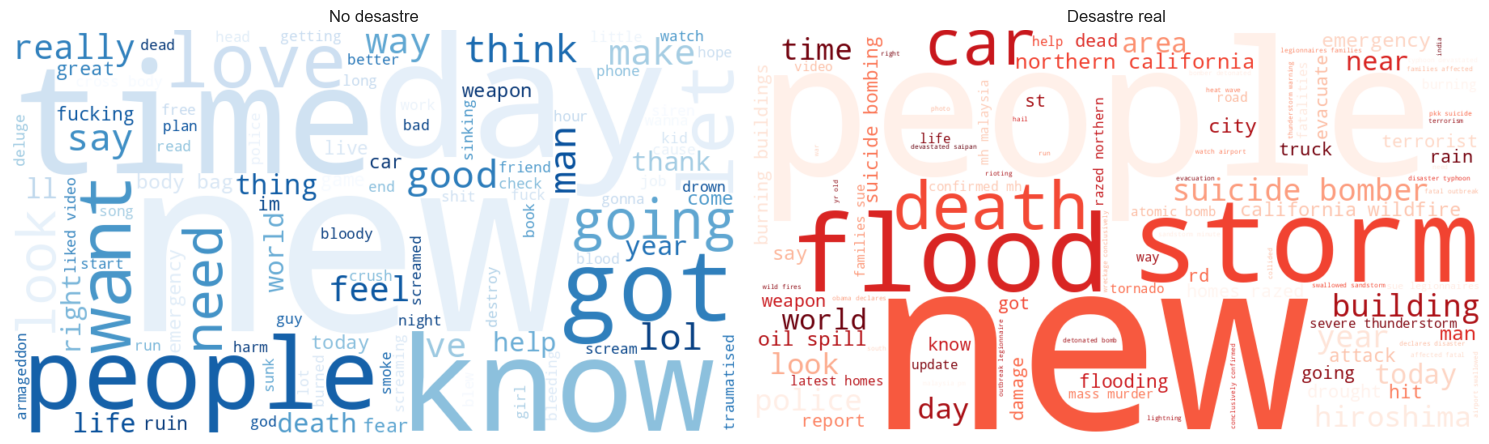

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for eje, target, titulo, mapa_color in [
    (ax[0], 0, "No desastre", "Blues"),
    (ax[1], 1, "Desastre real", "Reds"),
]:
    corpus = " ".join(datos_analisis.loc[datos_analisis["target"] == target, "texto_limpio"])
    nube = WordCloud(
        width=900,
        height=500,
        background_color="white",
        colormap=mapa_color,
        max_words=100,
        random_state=SEMILLA,
    ).generate(corpus)
    eje.imshow(nube, interpolation="bilinear")
    eje.set_title(titulo)
    eje.axis("off")

plt.tight_layout()
plt.show()

## 5. Unigramas y bigramas

Un unigrama es una palabra individual y un bigrama es una secuencia de dos palabras. Para cada clase se cuenta la frecuencia total y se calcula la probabilidad relativa dividiendo la frecuencia de cada término entre el total de n-gramas de esa clase.

In [8]:
def calcular_frecuencias_ngramas(textos, n, limite=15):
    vectorizador = CountVectorizer(ngram_range=(n, n), token_pattern=r"(?u)\b\w+\b")
    matriz = vectorizador.fit_transform(textos)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    tabla = pd.DataFrame({
        "ngrama": vectorizador.get_feature_names_out(),
        "frecuencia": frecuencias,
    })
    tabla["probabilidad"] = tabla["frecuencia"] / tabla["frecuencia"].sum()
    return tabla.nlargest(limite, "frecuencia").reset_index(drop=True)

tablas_ngramas = {}
for n, nombre in [(1, "unigramas"), (2, "bigramas")]:
    for target, clase in [(0, "no_desastre"), (1, "desastre_real")]:
        textos = datos_analisis.loc[datos_analisis["target"] == target, "texto_limpio"]
        tablas_ngramas[(nombre, clase)] = calcular_frecuencias_ngramas(textos, n)

for nombre in ["unigramas", "bigramas"]:
    print(nombre.upper())
    comparacion = pd.concat(
        {
            "No desastre": tablas_ngramas[(nombre, "no_desastre")],
            "Desastre real": tablas_ngramas[(nombre, "desastre_real")],
        },
        axis=1,
    )
    display(comparacion.style.format({
        ("No desastre", "probabilidad"): "{:.4f}",
        ("Desastre real", "probabilidad"): "{:.4f}",
    }))

UNIGRAMAS


BIGRAMAS


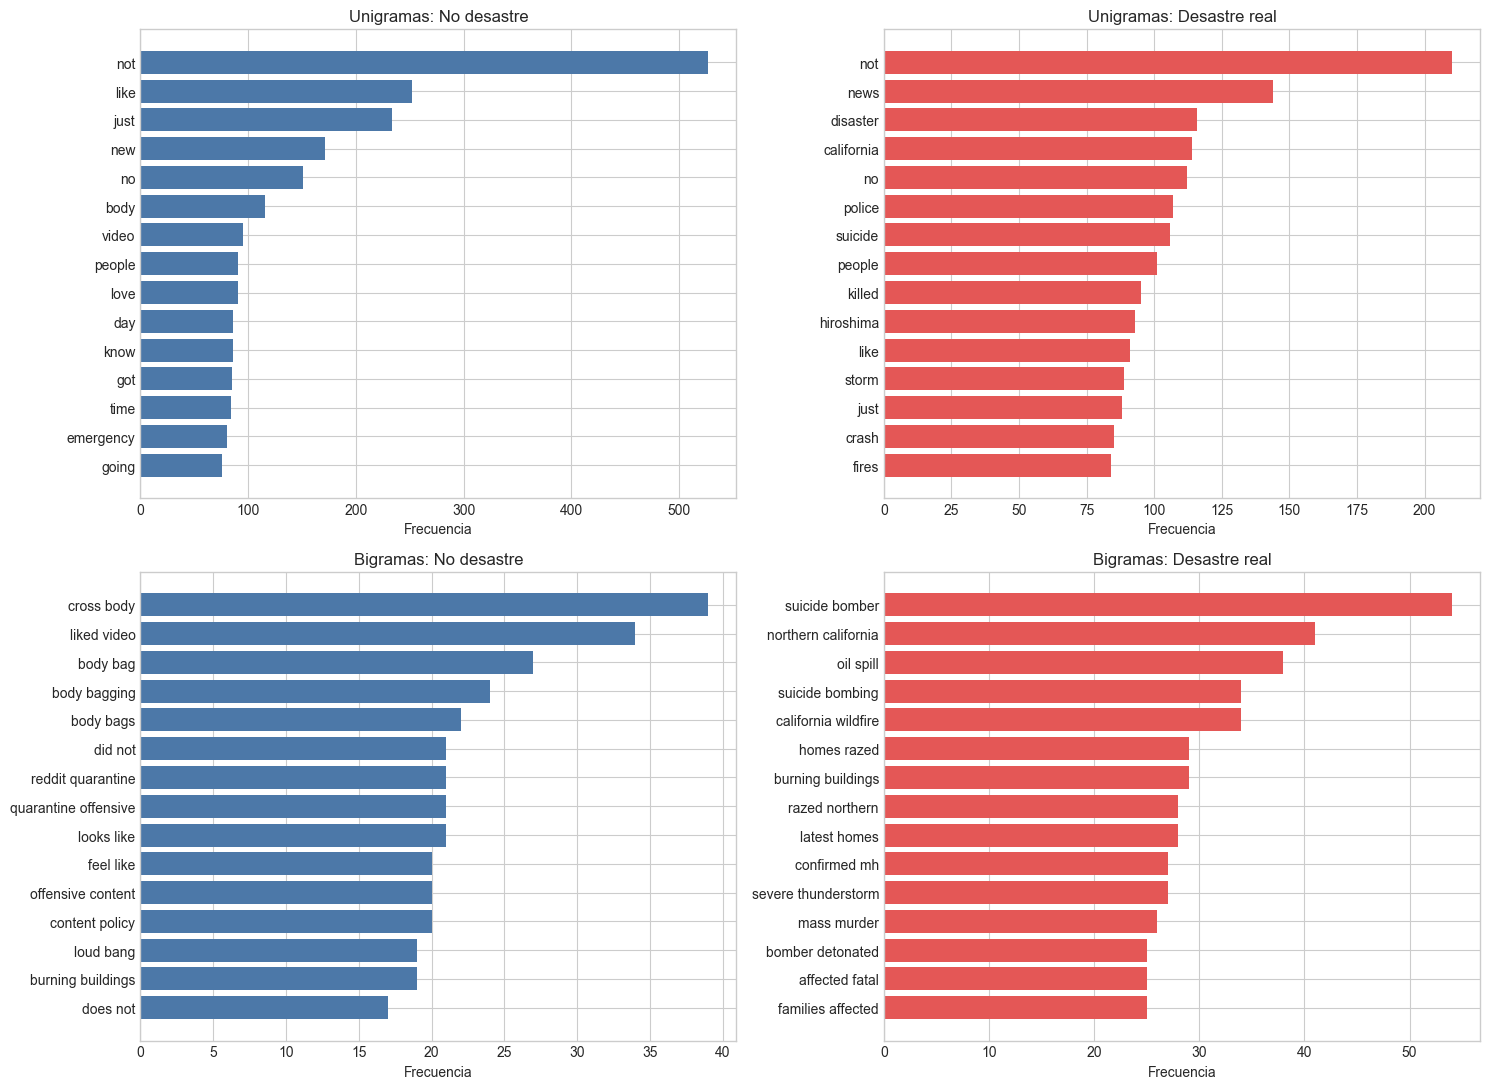

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(15, 11))

for fila, nombre in enumerate(["unigramas", "bigramas"]):
    for columna, (clase, titulo, color) in enumerate([
        ("no_desastre", "No desastre", "#4C78A8"),
        ("desastre_real", "Desastre real", "#E45756"),
    ]):
        tabla = tablas_ngramas[(nombre, clase)].sort_values("frecuencia")
        ax[fila, columna].barh(tabla["ngrama"], tabla["frecuencia"], color=color)
        ax[fila, columna].set_title(f"{nombre.capitalize()}: {titulo}")
        ax[fila, columna].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación de los n-gramas

En la clase 1 destacan unigramas como disaster, police, killed y storm. En la clase 0 aparecen términos más cotidianos como like, just, new y love. Palabras como people, like y not están presentes en ambas categorías, por lo que una palabra aislada no siempre permite distinguir el sentido literal del figurado.

Los bigramas agregan contexto local. En los desastres reales aparecen combinaciones como suicide bomber, northern california y oil spill. El bigrama burning buildings aparece en ambas clases, lo que confirma que incluso una frase relacionada con desastres puede utilizarse de forma literal o figurada. Vale la pena incluir unigramas y bigramas en el modelo preliminar, pero no se usan trigramas todavía porque son menos frecuentes y pueden aumentar demasiado la cantidad de variables.

## 6. Modelo preliminar de clasificación

Se utiliza regresión logística con representación TF-IDF. TF-IDF asigna más peso a los términos importantes de un tweet y reduce el peso de las palabras que aparecen en muchos documentos. El vectorizador usa unigramas y bigramas para incorporar contexto cercano.

Los datos se separan de forma estratificada: 80 % para entrenamiento y 20 % para prueba. El modelo usa class_weight=balanced para compensar el desbalance moderado, max_iter=1000 para asegurar la convergencia y random_state=42 para que la separación sea reproducible. Como referencia se incluye una línea base que siempre predice la clase mayoritaria.

In [10]:
datos_modelo = datos_analisis.loc[datos_analisis["texto_limpio"].ne("")].copy()
X = datos_modelo["text"]
y = datos_modelo["target"]

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y,
)

modelo_preliminar = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=limpiar_texto,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ("clasificador", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEMILLA,
    )),
])

modelo_preliminar.fit(X_entrenamiento, y_entrenamiento)
prediccion_modelo = modelo_preliminar.predict(X_prueba)
prediccion_base = np.repeat(y_entrenamiento.mode().iloc[0], len(y_prueba))

print(f"Entrenamiento: {len(X_entrenamiento):,} tweets")
print(f"Prueba: {len(X_prueba):,} tweets")

Entrenamiento: 5,984 tweets
Prueba: 1,496 tweets


,exactitud,precision_clase_1,recall_clase_1,f1_clase_1
Línea base,0.574,0.000,0.000,0.000
Regresión logística,0.781,0.761,0.708,0.733


,precision,recall,f1-score,support
No desastre,0.794,0.835,0.814,859.000
Desastre real,0.761,0.708,0.733,637.000
accuracy,0.781,0.781,0.781,0.781
macro avg,0.777,0.771,0.774,1496.000
weighted avg,0.780,0.781,0.780,1496.000


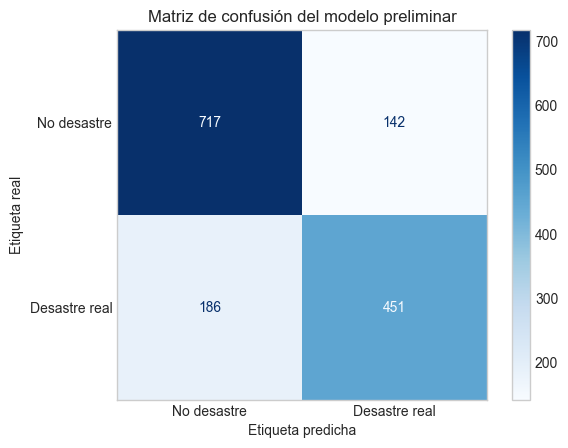

In [11]:
def obtener_metricas(y_real, y_predicho):
    return {
        "exactitud": accuracy_score(y_real, y_predicho),
        "precision_clase_1": precision_score(y_real, y_predicho, zero_division=0),
        "recall_clase_1": recall_score(y_real, y_predicho, zero_division=0),
        "f1_clase_1": f1_score(y_real, y_predicho, zero_division=0),
    }

metricas = pd.DataFrame({
    "Línea base": obtener_metricas(y_prueba, prediccion_base),
    "Regresión logística": obtener_metricas(y_prueba, prediccion_modelo),
}).T

reporte_clases = pd.DataFrame(
    classification_report(
        y_prueba,
        prediccion_modelo,
        target_names=["No desastre", "Desastre real"],
        output_dict=True,
        zero_division=0,
    )
).T

display(metricas.style.format("{:.3f}"))
display(reporte_clases.style.format("{:.3f}"))

ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    prediccion_modelo,
    display_labels=["No desastre", "Desastre real"],
    cmap="Blues",
)
plt.title("Matriz de confusión del modelo preliminar")
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.grid(False)
plt.show()

### Resultados del modelo preliminar

La línea base obtiene una exactitud de 0.574 y no detecta ningún desastre real. La regresión logística alcanza una exactitud de 0.781 y un F1 de 0.733 para la clase de desastre real. También obtiene una precisión de 0.761 y un recall de 0.708 en esa clase. El resultado es adecuado como punto de partida, pero todavía debe compararse con otros algoritmos y configuraciones antes de seleccionar el modelo final.

## 7. Conclusiones del avance

- El conjunto tiene un desbalance moderado, pero ambas clases cuentan con suficientes observaciones para entrenar y evaluar un modelo.
- La ubicación tiene muchos valores faltantes y no se incluyó en este primer modelo.
- La limpieza conserva palabras informativas de los hashtags y el número 911, y elimina elementos que generan ruido.
- Los unigramas ayudan a identificar términos relacionados con desastres, mientras que los bigramas aportan contexto para expresiones que pueden ser ambiguas.
- La regresión logística con TF-IDF sirve como modelo preliminar y ofrece una referencia para comparar los modelos de la entrega final.